# Company Clustering Analysis

This notebook visualizes the K-Means clustering used to group companies
by their interview problem patterns. It shows:

1. **Elbow plot** — inertia vs. k
2. **Silhouette plot** — silhouette score vs. k (how the optimal k is chosen)
3. **Cluster composition** — which companies are in each cluster
4. **PCHIP difficulty curves** — predicted easy/medium/hard mix per cluster over time
5. **2D projection** — PCA scatter plot of the feature space

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path(__file__).resolve().parent.parent if "__file__" in dir() else Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

from rag.curve_fitting import (
    _load_and_normalize,
    _load_company_features,
    _build_feature_matrix,
    _find_best_k,
    _fit_cluster_curves,
    AGGREGATED_PATH,
    TIME_BUCKETS,
    ANCHORED_BUCKETS,
    K_RANGE,
    COMPANY_META_PATH,
    INDUSTRY_WEIGHT,
)
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.facecolor"] = "white"

## 1. Load and prepare data

In [2]:
df = _load_and_normalize(AGGREGATED_PATH)
company_features = _load_company_features()
clusterable, sparse, pivot = _build_feature_matrix(df, company_features)

scaler = StandardScaler()
X = scaler.fit_transform(clusterable.values)
feature_cols = list(clusterable.columns)

if "industry_enc" in feature_cols:
    idx = feature_cols.index("industry_enc")
    X[:, idx] *= INDUSTRY_WEIGHT

print(f"Clusterable companies: {len(clusterable)}")
print(f"Sparse companies (assigned later): {len(sparse)}")
print(f"Feature dimensions: {len(feature_cols)}")
print(f"Features: {feature_cols}")

Clusterable companies: 453
Sparse companies (assigned later): 11
Feature dimensions: 4
Features: ['industry_enc', 'size_rank', 'log_employees', 'year_founded']


## 2. Elbow and Silhouette Plots

The **elbow plot** shows inertia (within-cluster sum of squares) decreasing as k increases.
The "elbow" is where adding more clusters stops giving significant improvement.

The **silhouette score** measures how well each point fits its assigned cluster vs. the nearest
other cluster. Higher is better. We pick the k with the highest silhouette score.

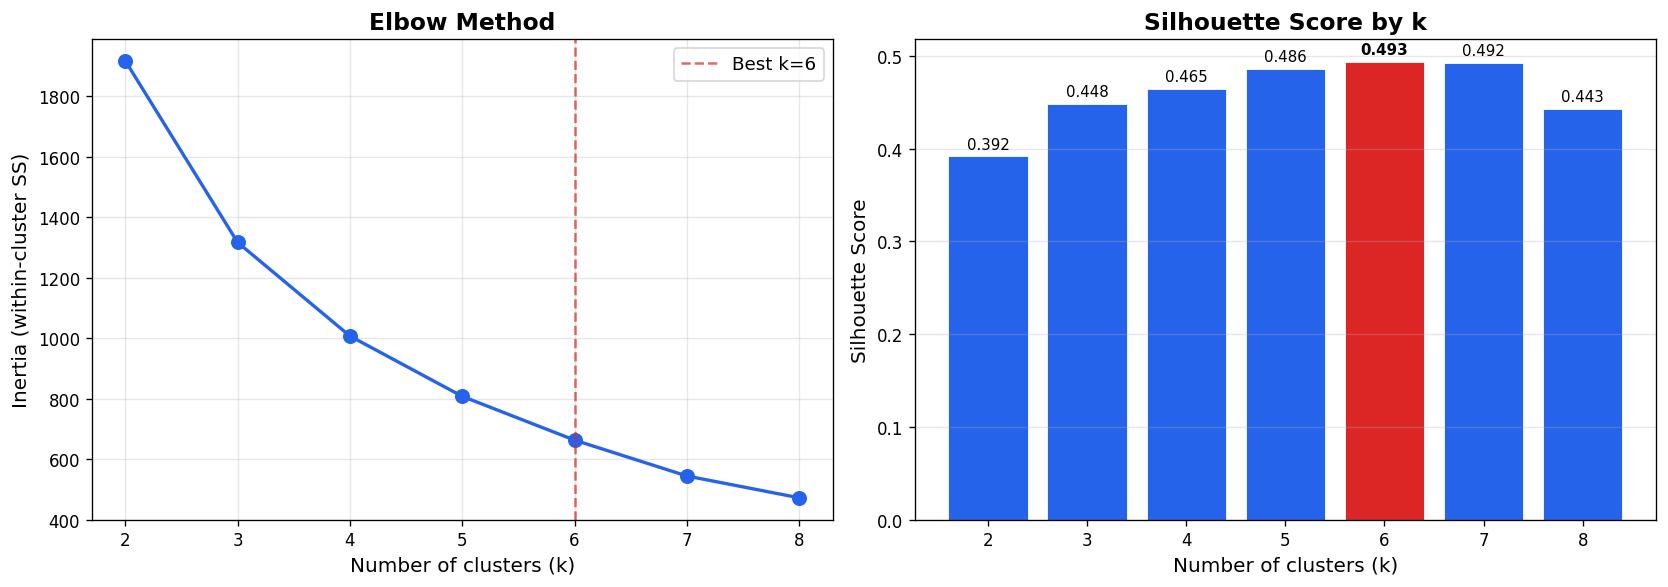


Optimal k = 6 (silhouette = 0.493)


In [3]:
k_range = list(K_RANGE)
if len(X) < max(k_range):
    k_range = list(range(2, max(3, len(X))))

results = []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels)
    results.append({"k": k, "inertia": km.inertia_, "silhouette": sil, "model": km, "labels": labels})

best = max(results, key=lambda r: r["silhouette"])
best_k = best["k"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ks = [r["k"] for r in results]
inertias = [r["inertia"] for r in results]
ax1.plot(ks, inertias, "o-", color="#2563eb", linewidth=2, markersize=8)
ax1.axvline(x=best_k, color="#dc2626", linestyle="--", alpha=0.7, label=f"Best k={best_k}")
ax1.set_xlabel("Number of clusters (k)", fontsize=12)
ax1.set_ylabel("Inertia (within-cluster SS)", fontsize=12)
ax1.set_title("Elbow Method", fontsize=14, fontweight="bold")
ax1.set_xticks(ks)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Silhouette plot
sils = [r["silhouette"] for r in results]
colors = ["#dc2626" if r["k"] == best_k else "#2563eb" for r in results]
ax2.bar(ks, sils, color=colors, edgecolor="white", linewidth=0.5)
ax2.set_xlabel("Number of clusters (k)", fontsize=12)
ax2.set_ylabel("Silhouette Score", fontsize=12)
ax2.set_title("Silhouette Score by k", fontsize=14, fontweight="bold")
ax2.set_xticks(ks)
ax2.grid(True, alpha=0.3, axis="y")

for i, (k_val, s) in enumerate(zip(ks, sils)):
    ax2.text(k_val, s + 0.005, f"{s:.3f}", ha="center", va="bottom", fontsize=9,
             fontweight="bold" if k_val == best_k else "normal")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "elbow_silhouette.png", bbox_inches="tight")
plt.show()

print(f"\nOptimal k = {best_k} (silhouette = {best['silhouette']:.3f})")

## 3. Silhouette Diagram per Sample

Shows how well each individual company fits into its cluster.
Wide bars = good fit, narrow/negative bars = borderline or misassigned.

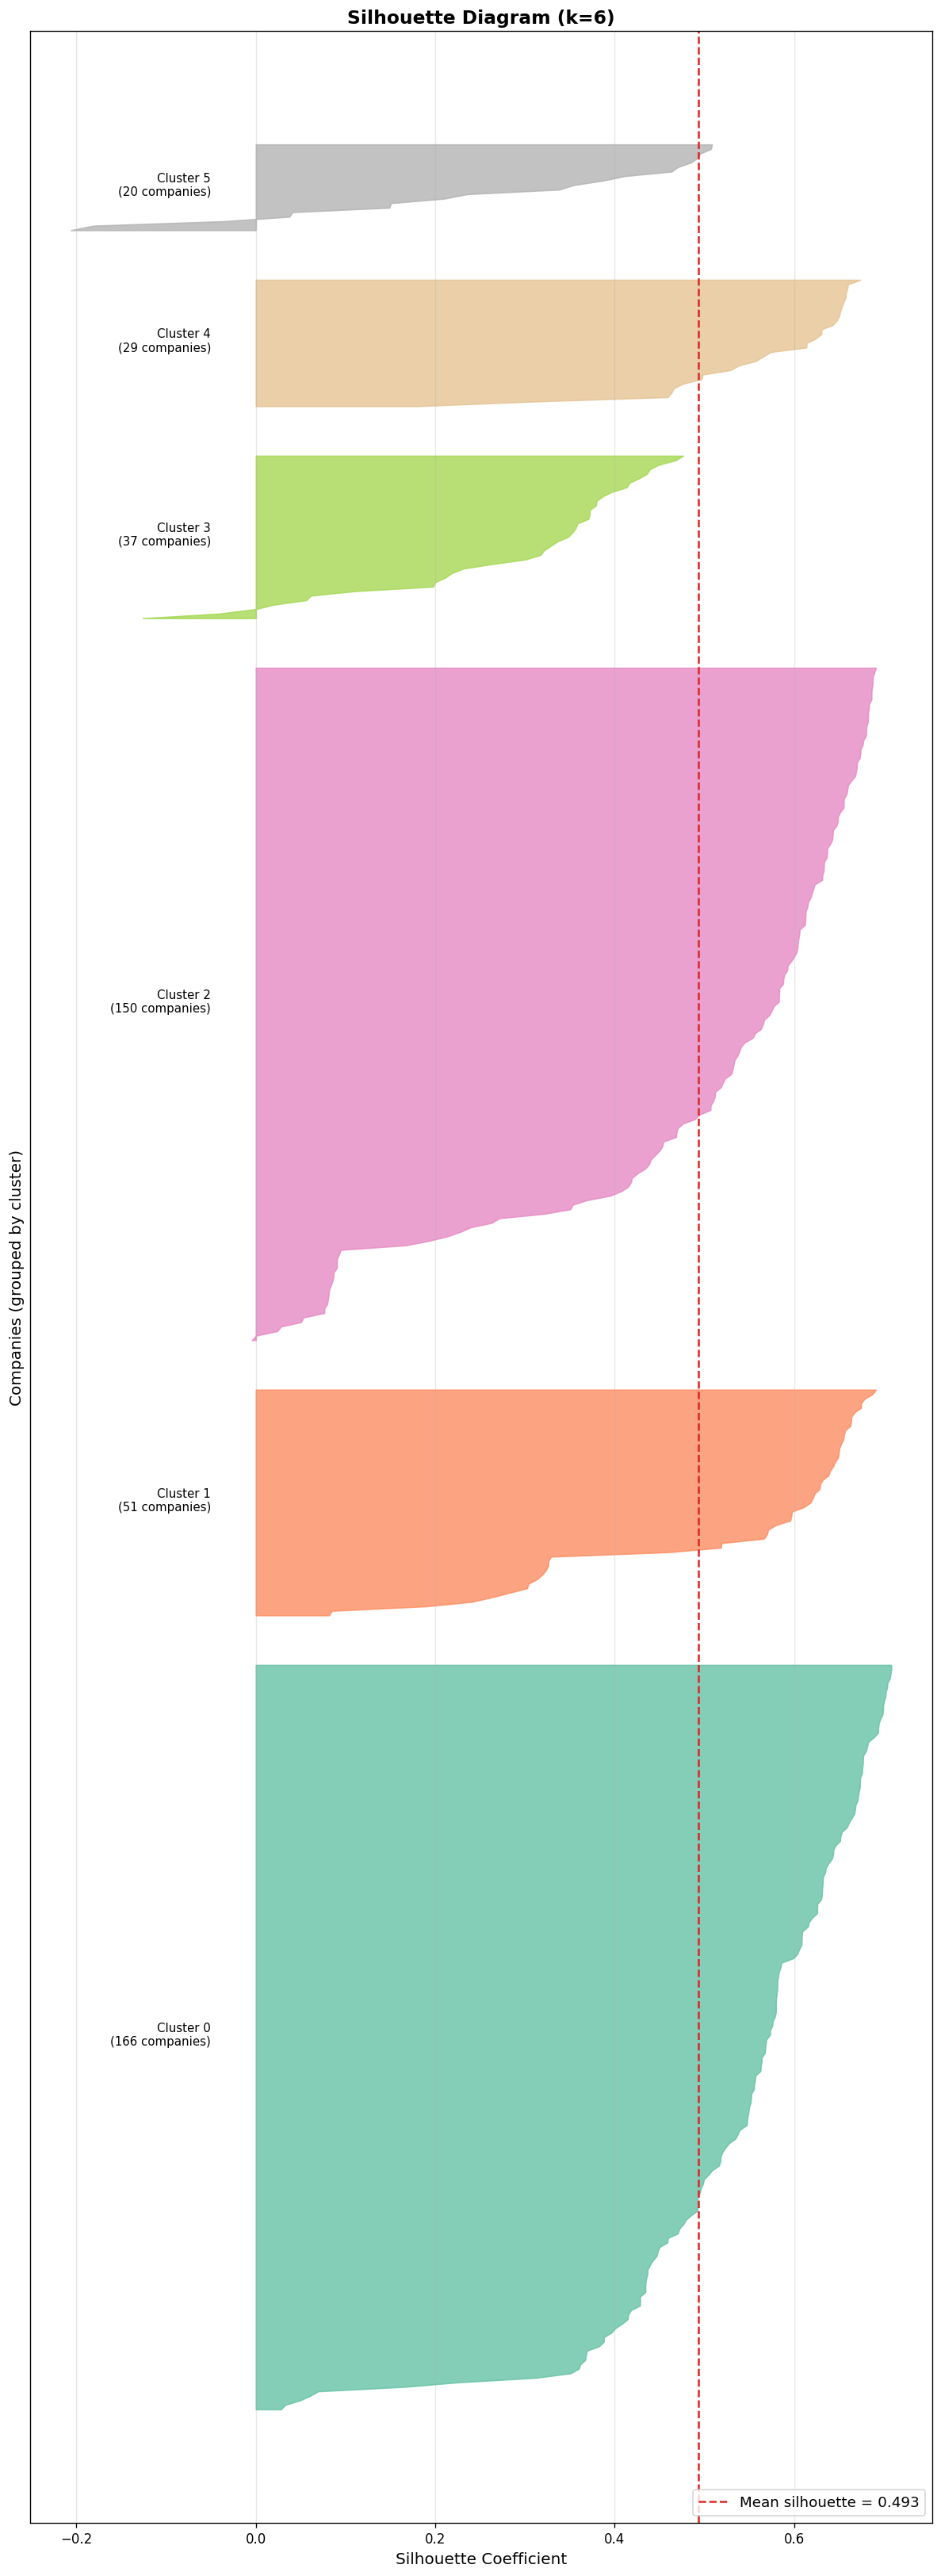

In [4]:
labels = best["labels"]
sample_sil = silhouette_samples(X, labels)

fig, ax = plt.subplots(figsize=(10, max(6, len(X) * 0.06)))

y_lower = 10
cmap = plt.cm.Set2

for i in range(best_k):
    cluster_sil = sample_sil[labels == i]
    cluster_sil.sort()
    size = cluster_sil.shape[0]
    y_upper = y_lower + size

    color = cmap(i / max(best_k - 1, 1))
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=color, edgecolor=color, alpha=0.8)
    ax.text(-0.05, y_lower + 0.5 * size, f"Cluster {i}\n({size} companies)",
            fontsize=9, va="center", ha="right")
    y_lower = y_upper + 10

ax.axvline(x=best["silhouette"], color="#dc2626", linestyle="--",
           label=f"Mean silhouette = {best['silhouette']:.3f}")
ax.set_xlabel("Silhouette Coefficient", fontsize=12)
ax.set_ylabel("Companies (grouped by cluster)", fontsize=12)
ax.set_title(f"Silhouette Diagram (k={best_k})", fontsize=14, fontweight="bold")
ax.set_yticks([])
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "silhouette_diagram.png", bbox_inches="tight")
plt.show()

## 4. Cluster Composition

Which companies are in each cluster, and how many.

In [5]:
company_cluster = {
    company: int(label)
    for company, label in zip(clusterable.index, labels)
}

cluster_df = pd.DataFrame([
    {"company": name, "cluster": cid}
    for name, cid in company_cluster.items()
]).sort_values(["cluster", "company"])

print("=" * 60)
print(f"CLUSTER SUMMARY (k={best_k})")
print("=" * 60)

for cid in range(best_k):
    members = cluster_df[cluster_df["cluster"] == cid]["company"].tolist()
    print(f"\nCluster {cid} — {len(members)} companies:")
    print("-" * 40)
    for i in range(0, len(members), 4):
        row = members[i:i+4]
        print("  " + ",  ".join(row))

CLUSTER SUMMARY (k=6)

Cluster 0 — 166 companies:
----------------------------------------
  AQR Capital Management,  Accolite,  Acko,  Affirm
  Agoda,  Airbnb,  Akamai,  Alibaba
  Amadeus,  Analytics quotient,  Arcesium,  Asana
  Attentive,  Audible,  Avito,  BitGo
  BlackStone,  Blizzard,  Bolt,  Box
  Braze,  Bridgewater Associates,  ByteDance,  CEDCOSS
  Careem,  Cashfree,  Cleartrip,  Cloudflare
  Cohesity,  Coinbase,  ConsultAdd,  Coupang
  Coursera,  Criteo,  DE Shaw,  DP world
  Darwinbox,  Dataminr,  Delhivery,  Deliveroo
  DeltaX,  Devtron,  Directi,  Disney
  DoorDash,  Dream11,  Dropbox,  Dunzo
  Edelweiss Group,  Flexport,  Freecharge,  FreshWorks
  GSA Capital,  GoDaddy,  Grab,  Grammarly
  Graviton,  Groww,  Grubhub,  HashedIn
  Hive,  Hiver,  Hotstar,  Houzz
  Hubspot,  Hulu,  IMC,  InMobi
  Indeed,  Instacart,  Juspay,  KLA
  Kakao,  LINE,  LTI,  Lenskart
  Licious,  LiveRamp,  MAQ Software,  MakeMyTrip
  Media.net,  Meesho,  Mercari,  Meta
  Millennium,  Mindtickle,  

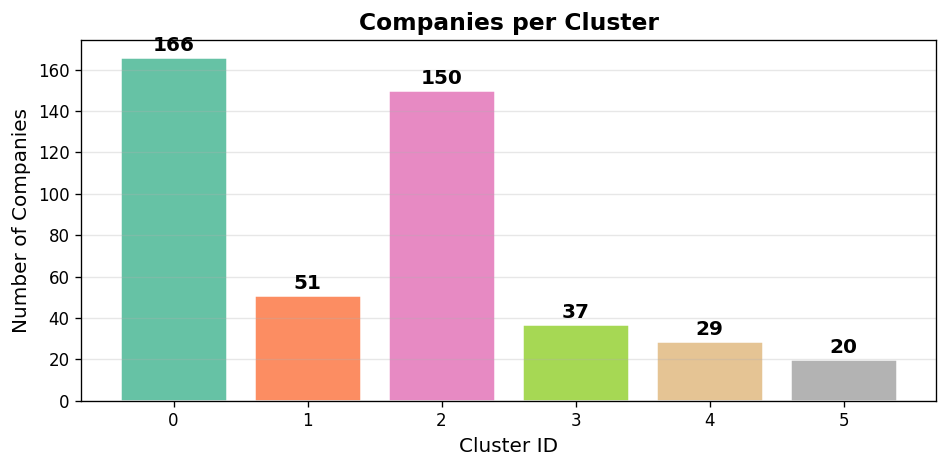

In [6]:
# Cluster size bar chart
sizes = cluster_df["cluster"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
cmap = plt.cm.Set2
bars = ax.bar(sizes.index, sizes.values,
              color=[cmap(i / max(best_k - 1, 1)) for i in sizes.index],
              edgecolor="white", linewidth=1.5)

for bar, count in zip(bars, sizes.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            str(count), ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_xlabel("Cluster ID", fontsize=12)
ax.set_ylabel("Number of Companies", fontsize=12)
ax.set_title("Companies per Cluster", fontsize=14, fontweight="bold")
ax.set_xticks(sizes.index)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "cluster_sizes.png", bbox_inches="tight")
plt.show()

## 5. PCHIP Difficulty Curves per Cluster

Each cluster has fitted PCHIP interpolation curves that predict the
proportion of easy/medium/hard problems as a function of days until interview.

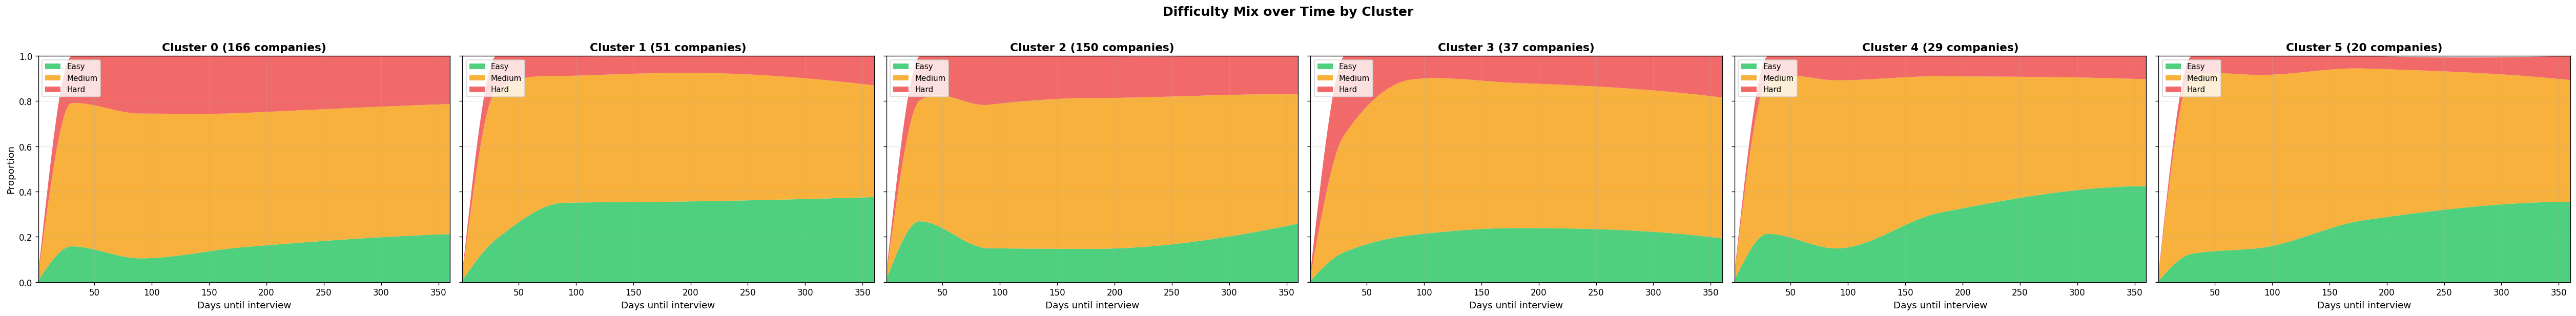

In [7]:
curves = _fit_cluster_curves(df, company_cluster)

days = np.linspace(1, 360, 300)
n_clusters = len(curves)
fig, axes = plt.subplots(1, n_clusters, figsize=(7 * n_clusters, 5), sharey=True)
if n_clusters == 1:
    axes = [axes]

for idx, (cid, curve_data) in enumerate(sorted(curves.items())):
    ax = axes[idx]
    n_comp = curve_data["n_companies"]

    easy_vals = np.clip(curve_data["easy_pct"](days), 0, 1)
    med_vals = np.clip(curve_data["medium_pct"](days), 0, 1)
    hard_vals = np.clip(curve_data["hard_pct"](days), 0, 1)

    ax.stackplot(days, easy_vals, med_vals, hard_vals,
                 labels=["Easy", "Medium", "Hard"],
                 colors=["#22c55e", "#f59e0b", "#ef4444"], alpha=0.8)

    ax.set_xlabel("Days until interview", fontsize=11)
    if idx == 0:
        ax.set_ylabel("Proportion", fontsize=11)
    ax.set_title(f"Cluster {cid} ({n_comp} companies)", fontsize=13, fontweight="bold")
    ax.legend(loc="upper left", fontsize=9)
    ax.set_xlim(1, 360)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

plt.suptitle("Difficulty Mix over Time by Cluster", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "difficulty_curves.png", bbox_inches="tight")
plt.show()

## 6. Total Problem Proportion Curves

How quickly each cluster ramps up its problem pool as the interview window grows.

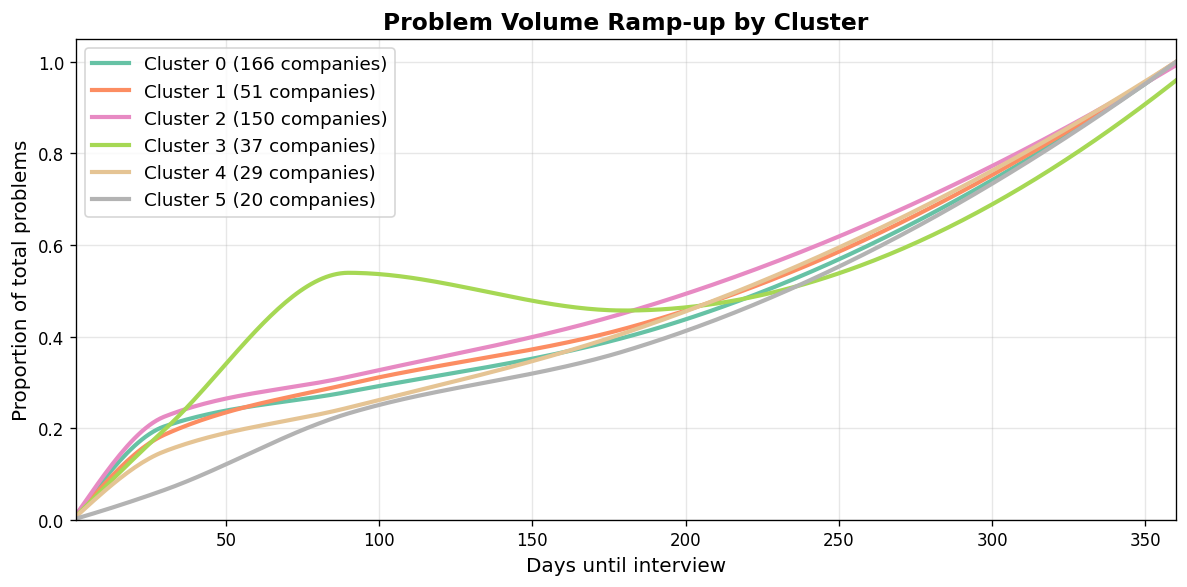

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
cmap = plt.cm.Set2

for cid, curve_data in sorted(curves.items()):
    prop_vals = np.clip(curve_data["proportion"](days), 0, 1)
    color = cmap(cid / max(n_clusters - 1, 1))
    ax.plot(days, prop_vals, linewidth=2.5, color=color,
            label=f"Cluster {cid} ({curve_data['n_companies']} companies)")

ax.set_xlabel("Days until interview", fontsize=12)
ax.set_ylabel("Proportion of total problems", fontsize=12)
ax.set_title("Problem Volume Ramp-up by Cluster", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.set_xlim(1, 360)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "proportion_curves.png", bbox_inches="tight")
plt.show()

## 7. PCA 2D Projection

Projects the full feature space down to 2 dimensions to visualize
cluster separation. Each dot is a company.

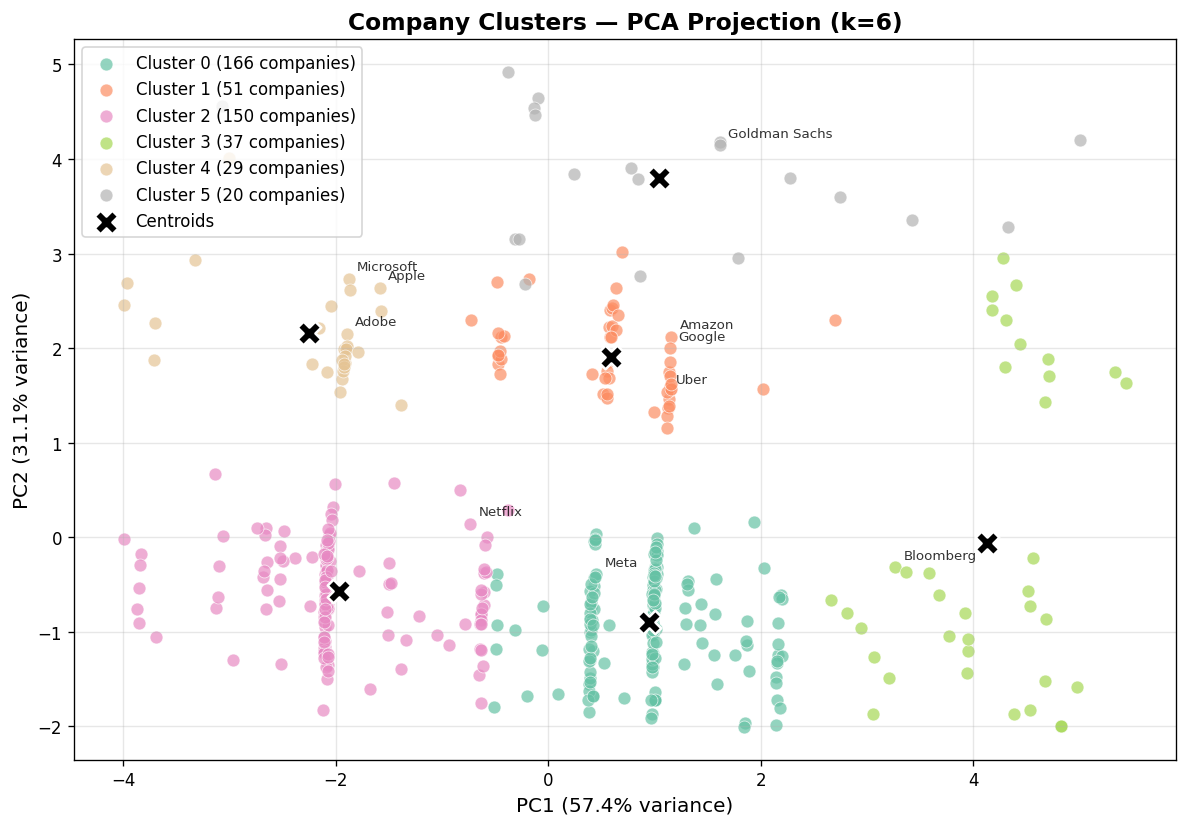


PCA explained variance: PC1=57.4%, PC2=31.1%, total=88.6%


In [9]:
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(10, 7))
cmap = plt.cm.Set2

for cid in range(best_k):
    mask = labels == cid
    color = cmap(cid / max(best_k - 1, 1))
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=[color], s=60, alpha=0.7, edgecolors="white", linewidth=0.5,
               label=f"Cluster {cid} ({mask.sum()} companies)")

# Label notable companies
notable = ["Google", "Amazon", "Apple", "Microsoft", "Meta", "Adobe",
           "Goldman Sachs", "Bloomberg", "Uber", "Netflix"]
companies_list = list(clusterable.index)
for name in notable:
    if name in companies_list:
        idx = companies_list.index(name)
        ax.annotate(name, (X_2d[idx, 0], X_2d[idx, 1]),
                    fontsize=8, alpha=0.8,
                    xytext=(5, 5), textcoords="offset points")

# Plot centroids
centroids_2d = pca.transform(best["model"].cluster_centers_)
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
           c="black", marker="X", s=200, edgecolors="white", linewidth=1.5,
           zorder=10, label="Centroids")

explained = pca.explained_variance_ratio_
ax.set_xlabel(f"PC1 ({explained[0]:.1%} variance)", fontsize=12)
ax.set_ylabel(f"PC2 ({explained[1]:.1%} variance)", fontsize=12)
ax.set_title(f"Company Clusters — PCA Projection (k={best_k})", fontsize=14, fontweight="bold")
ax.legend(fontsize=10, loc="best")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "pca_clusters.png", bbox_inches="tight")
plt.show()

print(f"\nPCA explained variance: PC1={explained[0]:.1%}, PC2={explained[1]:.1%}, total={sum(explained):.1%}")

## 8. Feature Importance

How much each feature dimension contributes to the cluster separation.

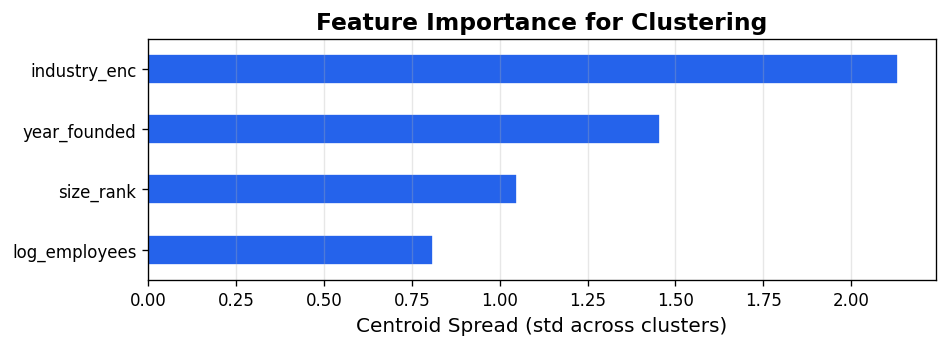

In [10]:
# Centroid spread per feature: std of centroids across clusters
centroids = best["model"].cluster_centers_
centroid_std = centroids.std(axis=0)

feat_importance = pd.Series(centroid_std, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, max(3, len(feature_cols) * 0.5)))
feat_importance.plot.barh(ax=ax, color="#2563eb", edgecolor="white")
ax.set_xlabel("Centroid Spread (std across clusters)", fontsize=12)
ax.set_title("Feature Importance for Clustering", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "feature_importance.png", bbox_inches="tight")
plt.show()

## 9. Summary Table

In [13]:
summary_rows = []
for cid in range(best_k):
    members = cluster_df[cluster_df["cluster"] == cid]["company"].tolist()
    curve = curves[cid]

    easy_30 = float(np.clip(curve["easy_pct"](30), 0, 1))
    med_30 = float(np.clip(curve["medium_pct"](30), 0, 1))
    hard_30 = float(np.clip(curve["hard_pct"](30), 0, 1))

    summary_rows.append({
        "Cluster": cid,
        "Companies": len(members),
        "Easy % (30d)": f"{easy_30:.0%}",
        "Medium % (30d)": f"{med_30:.0%}",
        "Hard % (30d)": f"{hard_30:.0%}",
        "Top companies": ", ".join(members[:6]) + ("..." if len(members) > 6 else ""),
    })

summary = pd.DataFrame(summary_rows)
print(f"Cluster Summary (k={best_k}, silhouette={best['silhouette']:.3f})")
display(summary)

Cluster Summary (k=6, silhouette=0.493)


,Cluster,Companies,Easy % (30d),Medium % (30d),Hard % (30d),Top companies
0,0,166,16%,63%,21%,"AQR Capital Management, Accolite, Acko, Affirm..."
1,1,51,19%,66%,16%,"Accenture, Amazon, Aon, BNY Mellon, Baidu, Bar..."
2,2,150,27%,53%,20%,"Activision, Airbus SE, Airwallex, Akuna Capita..."
3,3,37,13%,52%,35%,"AMD, Airtel, Amdocs, Axon, Bloomberg, Cadence..."
4,4,29,21%,68%,11%,"Adobe, Apple, Autodesk, Bank of America, Cisco..."
5,5,20,12%,79%,8%,"American Express, BP, Bosch, CME Group, Deloit..."
